In [6]:
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd

In [7]:
dataset=pd.read_csv('Churn_Modelling.csv')
dataset.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [8]:
y = dataset["Exited"]
x = dataset.iloc[:, 3:13]  


x["BalanceSalaryRatio"] = x["Balance"] / (x["EstimatedSalary"] + 1)
x["TenureByAge"]        = x["Tenure"] / x["Age"]
x["CreditScoreByAge"]   = x["CreditScore"] / x["Age"]
x["ZeroBalance"]        = (x["Balance"] == 0).astype(int)
x["IsSenior"]           = (x["Age"] >= 60).astype(int)
x["Age_x_Active"]       = x["Age"] * x["IsActiveMember"]

# Age bins -> one-hot
x["AgeBin"] = pd.cut(x["Age"], bins=[0, 30, 45, 60, 100],
                     labels=["Young", "Adult", "MidAge", "Senior"])
age_dummies = pd.get_dummies(x["AgeBin"], prefix="Age", drop_first=True)

#NumOfProducts is non-monotonic -> treat as categorical
prod_dummies = pd.get_dummies(x["NumOfProducts"], prefix="Products", drop_first=True)

#Geography & Gender -> one-hot
geo_dummies    = pd.get_dummies(x["Geography"], prefix="Geo", drop_first=True)
gender_dummies = pd.get_dummies(x["Gender"],    prefix="Gender", drop_first=True)

x = pd.concat([x, age_dummies, prod_dummies, geo_dummies, gender_dummies], axis=1)
x = x.drop(["Geography", "Gender", "AgeBin", "NumOfProducts"], axis=1)

print(x.shape)
x.head()

(10000, 22)


,CreditScore,Age,Tenure,Balance,HasCrCard,IsActiveMember,EstimatedSalary,BalanceSalaryRatio,TenureByAge,CreditScoreByAge,...,Age_x_Active,Age_Adult,Age_MidAge,Age_Senior,Products_2,Products_3,Products_4,Geo_Germany,Geo_Spain,Gender_Male
0,619,42,2,0.00,1,1,101348.88,0.000000,0.047619,14.738095,...,42,True,False,False,False,False,False,False,False,False
1,608,41,1,83807.86,0,1,112542.58,0.744670,0.024390,14.829268,...,41,True,False,False,False,False,False,False,True,False
2,502,42,8,159660.80,1,0,113931.57,1.401362,0.190476,11.952381,...,0,True,False,False,False,True,False,False,False,False
3,699,39,1,0.00,0,0,93826.63,0.000000,0.025641,17.923077,...,0,True,False,False,True,False,False,False,False,False
4,850,43,2,125510.82,1,1,79084.10,1.587035,0.046512,19.767442,...,43,True,False,False,False,False,False,False,True,False


In [9]:
x.head()

,CreditScore,Age,Tenure,Balance,HasCrCard,IsActiveMember,EstimatedSalary,BalanceSalaryRatio,TenureByAge,CreditScoreByAge,...,Age_x_Active,Age_Adult,Age_MidAge,Age_Senior,Products_2,Products_3,Products_4,Geo_Germany,Geo_Spain,Gender_Male
0,619,42,2,0.00,1,1,101348.88,0.000000,0.047619,14.738095,...,42,True,False,False,False,False,False,False,False,False
1,608,41,1,83807.86,0,1,112542.58,0.744670,0.024390,14.829268,...,41,True,False,False,False,False,False,False,True,False
2,502,42,8,159660.80,1,0,113931.57,1.401362,0.190476,11.952381,...,0,True,False,False,False,True,False,False,False,False
3,699,39,1,0.00,0,0,93826.63,0.000000,0.025641,17.923077,...,0,True,False,False,True,False,False,False,False,False
4,850,43,2,125510.82,1,1,79084.10,1.587035,0.046512,19.767442,...,43,True,False,False,False,False,False,False,True,False


In [10]:
y.head()

0    1
1    0
2    1
3    0
4    0
Name: Exited, dtype: int64

In [11]:
x.head()

,CreditScore,Age,Tenure,Balance,HasCrCard,IsActiveMember,EstimatedSalary,BalanceSalaryRatio,TenureByAge,CreditScoreByAge,...,Age_x_Active,Age_Adult,Age_MidAge,Age_Senior,Products_2,Products_3,Products_4,Geo_Germany,Geo_Spain,Gender_Male
0,619,42,2,0.00,1,1,101348.88,0.000000,0.047619,14.738095,...,42,True,False,False,False,False,False,False,False,False
1,608,41,1,83807.86,0,1,112542.58,0.744670,0.024390,14.829268,...,41,True,False,False,False,False,False,False,True,False
2,502,42,8,159660.80,1,0,113931.57,1.401362,0.190476,11.952381,...,0,True,False,False,False,True,False,False,False,False
3,699,39,1,0.00,0,0,93826.63,0.000000,0.025641,17.923077,...,0,True,False,False,True,False,False,False,False,False
4,850,43,2,125510.82,1,1,79084.10,1.587035,0.046512,19.767442,...,43,True,False,False,False,False,False,False,True,False


In [12]:
# splitting the datset into training and test 
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=0)

In [13]:
# feature scaling

from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
x_train=sc.fit_transform(x_train)
x_test=sc.transform(x_test)

In [14]:
x_train

array([[ 0.16958176, -0.46460796,  0.00666099, ..., -0.5698444 ,
         1.74309049, -1.09168714],
       [-2.30455945,  0.30102557, -1.37744033, ...,  1.75486502,
        -0.57369368,  0.91601335],
       [-1.19119591, -0.94312892, -1.031415  , ..., -0.5698444 ,
        -0.57369368, -1.09168714],
       ...,
       [ 0.9015152 , -0.36890377,  0.00666099, ..., -0.5698444 ,
        -0.57369368,  0.91601335],
       [-0.62420521, -0.08179119,  1.39076231, ..., -0.5698444 ,
         1.74309049, -1.09168714],
       [-0.28401079,  0.87525072, -1.37744033, ...,  1.75486502,
        -0.57369368, -1.09168714]], shape=(8000, 22))

In [15]:
x_test

array([[-0.55204276, -0.36890377,  1.04473698, ...,  1.75486502,
        -0.57369368, -1.09168714],
       [-1.31490297,  0.10961719, -1.031415  , ..., -0.5698444 ,
        -0.57369368, -1.09168714],
       [ 0.57162971,  0.30102557,  1.04473698, ..., -0.5698444 ,
         1.74309049, -1.09168714],
       ...,
       [-0.74791227, -0.27319958, -1.37744033, ..., -0.5698444 ,
         1.74309049,  0.91601335],
       [-0.00566991, -0.46460796, -0.33936434, ...,  1.75486502,
        -0.57369368,  0.91601335],
       [-0.79945688, -0.84742473,  1.04473698, ...,  1.75486502,
        -0.57369368,  0.91601335]], shape=(2000, 22))

In [16]:
x_train.shape

(8000, 22)

In [17]:
x_test.shape

(2000, 22)

In [18]:
#Creating ANN
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import LeakyReLU,PReLU,ELU,ReLU
from tensorflow.keras.layers import Dropout

In [19]:
#initialising ANN
classifier=Sequential()

In [20]:
#adding input layer
classifier.add(Dense(units=x_train.shape[1],activation='relu'))

In [21]:
#adding first hidden layer
classifier.add(Dense(units=7,activation='relu'))
classifier.add(Dropout(0.2))

In [22]:
#classifier the second hidden layer and adding dropout layer
classifier.add(Dense(units=6,activation='relu'))
classifier.add(Dropout(0.3))

In [23]:
#adding output layer
classifier.add(Dense(1,activation='sigmoid'))

In [24]:
classifier.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [25]:
#early stopping----Stop training when a monitored metric has stopped improving.
import tensorflow as tf
early_stopping=tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    min_delta=0.0001,
    patience=20,
    verbose=1,
    mode="auto",
    baseline=None,
    restore_best_weights=False,
)

In [26]:
model_history=classifier.fit(x_train,y_train,validation_split=0.33,batch_size=10,epochs=1000,callbacks=early_stopping)

Epoch 1/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 1s 870us/step - accuracy: 0.7733 - loss: 0.5183 - val_accuracy: 0.7955 - val_loss: 0.4083
Epoch 2/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 0s 726us/step - accuracy: 0.8007 - loss: 0.4277 - val_accuracy: 0.8122 - val_loss: 0.3907
Epoch 3/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 0s 804us/step - accuracy: 0.8255 - loss: 0.4044 - val_accuracy: 0.8436 - val_loss: 0.3758
Epoch 4/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 0s 881us/step - accuracy: 0.8321 - loss: 0.3936 - val_accuracy: 0.8470 - val_loss: 0.3707
Epoch 5/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 0s 714us/step - accuracy: 0.8296 - loss: 0.3888 - val_accuracy: 0.8519 - val_loss: 0.3674
Epoch 6/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 0s 727us/step - accuracy: 0.8319 - loss: 0.3883 - val_accuracy: 0.8478 - val_loss: 0.3651
Epoch 7/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 0s 704us/step - accuracy: 0.8336 - loss: 0.3773 - val_accuracy: 0.8489 - val_loss: 0.3628
Epoch 8/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 0s 669us/step - accuracy: 0.8309 -

In [27]:
model_history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

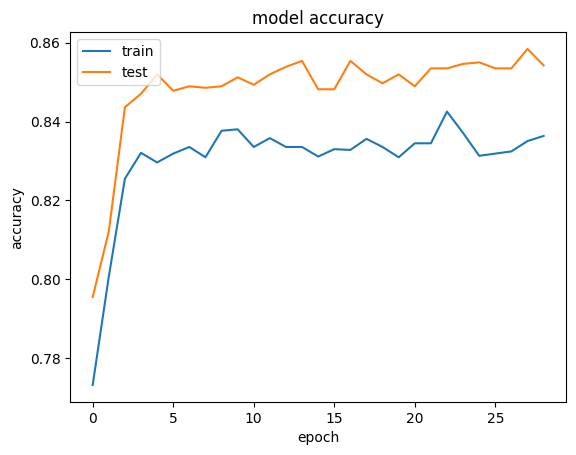

In [28]:
#summarise history for accuracy
plt.plot(model_history.history['accuracy'])
plt.plot(model_history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train','test'],loc='upper left')
plt.show()

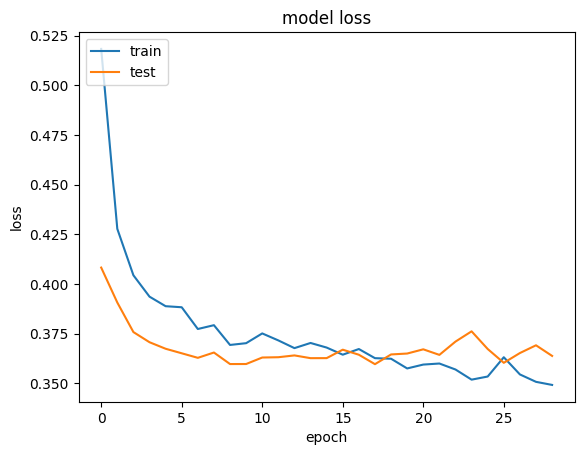

In [29]:
#summarise history for loss
plt.plot(model_history.history['loss'])
plt.plot(model_history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train','test'],loc='upper left')
plt.show()

In [ ]:
# part 3- making the predictions and evaluating the model
y_pred=classifier.predict(x_test)
y_pred=(y_pred>0.5)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 549us/step


In [31]:
# make the confusion matrix
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y_test,y_pred)
cm

array([[1534,   61],
       [ 212,  193]])

In [32]:
## calculate the accuracy
from sklearn.metrics import accuracy_score
score=accuracy_score(y_pred,y_test)

In [33]:
score

0.8635

In [34]:
## get the weights
classifier.get_weights()

[array([[ 0.37139484, -0.12841497, -0.19659431, -0.3056556 , -0.27918926,
          0.24289778,  0.243507  ,  0.12949581, -0.26046845,  0.01408965,
          0.3101683 , -0.1538176 , -0.28136063, -0.3277527 ,  0.20487739,
         -0.05091965, -0.08710244, -0.10462739, -0.21104196, -0.3937361 ,
          0.36363295,  0.268432  ],
        [ 0.09482819,  0.2996521 ,  0.19094989, -0.40312892,  0.28301284,
          0.28241235, -0.0127935 ,  0.16889177,  0.67266625, -0.18741253,
         -0.46407622,  0.08913051, -0.4338396 , -0.5071588 , -0.14708264,
         -0.233613  ,  0.06618705,  0.2625787 ,  0.22147277, -0.19991829,
         -0.08010765, -0.0812929 ],
        [-0.07201523,  0.18733458,  0.3761941 , -0.19175972,  0.12293158,
          0.05472799, -0.21411927,  0.12950984, -0.17505378,  0.1717871 ,
         -0.4067142 ,  0.0163646 , -0.1211301 , -0.35207996,  0.2265148 ,
         -0.04071774,  0.00748909,  0.18479384,  0.07347787,  0.02806868,
          0.00255932, -0.09306221],
    